In [2]:
import copy
import random
import gymnasium as gym
import numpy as np
from datetime import datetime, timedelta
import pickle
import pandas as pd
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import imageio.v2 as imageio

In [3]:
class Config():
    def __init__(self):
        # env
        self.env_name = "Taxi-v4"
        self.gamma = 0.99
        self.num_action = 6
        self.state_dim = 1

        # replay
        self.buffer_size = 30000
        self.batch_size = 64

        # training
        self.total_episodes = None
        self.total_steps = 1000000
        self.learning_rate = 5e-4
        self.max_gradient_norm = 10
        self.loss_type = "huber"

        self.start_training_step = 1000
        self.train_frequency = 4
        self.test_frequency = 1000 # 1000
        self.save_frequency = 100000000 # Don't save

        ## target network
        self.use_soft_update = True
        self.update_frequency = 100
        self.tau = 0.005

        ## episode
        self.init_epsilon = 1.
        self.end_epsilon = 0.05
        self.exploration_fraction = 0.15

        self.seed = 1
        self.test_seeds = [
    1001, 1003, 1007, 1009, 1013, 1019, 1021, 1031, 1033, 1039,
    1049, 1051, 1061, 1063, 1069, 1087, 1091, 1093, 1097, 1103,
    1109, 1117, 1123, 1129, 1151, 1153, 1163, 1171, 1181, 1187,
    1193, 1201, 1213, 1217, 1223, 1229, 1231, 1237, 1249, 1259,
    1277, 1279, 1283, 1289, 1291, 1297, 1301, 1303, 1307, 1319,
    1321, 1327, 1361, 1367, 1373, 1381, 1399, 1409, 1423, 1427,
    1429, 1433, 1439, 1447, 1451, 1453, 1459, 1471, 1481, 1483,
    1487, 1489, 1493, 1499, 1511, 1523, 1531, 1543, 1549, 1553,
    1559, 1567, 1571, 1579, 1583, 1597, 1601, 1607, 1609, 1613,
    1619, 1621, 1627, 1637, 1657, 1663, 1667, 1669, 1693, 1697
]
        #[1, 2, 3, 5, 7, 11, 13, 17, 19, 20]
        self.save_file = "weights/DQN-Taxi-v4-1M-run1"

config = Config()

In [4]:
random.seed(config.seed)
np.random.seed(config.seed)

In [5]:
class Replay_Buffer():
    def __init__(self, buffer_size, state_dim):
        self.buffer_size = buffer_size
        self.real_size = 0
        self.index = 0

        self.states = np.zeros((buffer_size, state_dim))
        self.actions = np.zeros((buffer_size,))
        self.rewards = np.zeros((buffer_size,))
        self.dones = np.zeros((buffer_size,), dtype = bool)
        self.next_states = np.zeros((buffer_size, state_dim))

    def add(self, state, action, reward, next_state, done):
        self.states[self.index] = state
        self.actions[self.index] = action
        self.rewards[self.index] = reward
        self.next_states[self.index] = next_state
        self.dones[self.index] = done

        self.real_size = min(self.real_size+1, self.buffer_size)
        self.index = (self.index+1) % self.buffer_size

    def sample(self, batchsize):
        idxs = np.random.choice(self.real_size, batchsize, replace=False).astype(np.int64)
        return torch.tensor(self.states[idxs]).float(), \
                torch.tensor(self.actions[idxs]).long().reshape(-1), \
                    torch.tensor(self.rewards[idxs]).float().reshape(-1), \
                        torch.tensor(self.next_states[idxs]).float(), torch.tensor(self.dones[idxs].astype(np.float32)).reshape(-1)


In [6]:
class Model(nn.Module):
    def __init__(self, state_dim=4, num_action=2):
        super(Model, self).__init__()
        self.state_dim = state_dim
        self.fc = nn.Linear(self.state_dim, 64)
        #self.fc2 = nn.Linear(64, 64)
        self.Q = nn.Linear(64, num_action)

    def forward(self, state):
        x = F.one_hot(state.long(), 500).float().reshape(-1, self.state_dim)
        x = F.elu(self.fc(x))
        #x = F.elu(self.fc2(x))
        Q = self.Q(x)
        return Q

In [7]:
class Agent():
    def __init__(self, model, target_model, replay_buffer, config):
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        self.model = model.to(self.device)
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=config.learning_rate)
        self.target_model = target_model.to(self.device)
        self.replay_buffer = replay_buffer

        self.env_name = config.env_name
        self.gamma = config.gamma
        self.num_action = config.num_action
        self.state_dim = config.state_dim

        # replay
        self.buffer_size = config.buffer_size
        self.batch_size = config.batch_size

        # training
        self.total_episodes = config.total_episodes
        self.total_steps = config.total_steps
        self.learning_rate = config.learning_rate
        self.max_gradient_norm = config.max_gradient_norm
        self.loss_type = config.loss_type
        self.start_training_step = config.start_training_step
        self.train_frequency = config.train_frequency
        self.test_frequency = config.test_frequency
        self.save_frequency = config.save_frequency

        ## target network
        self.use_soft_update = config.use_soft_update
        self.update_frequency = config.update_frequency
        self.tau = config.tau

        ## episode
        self.init_epsilon = config.init_epsilon
        self.end_epsilon = config.end_epsilon
        self.exploration_fraction = config.exploration_fraction
        self.epsilon = self.init_epsilon
        
        if self.total_episodes is not None:
            self.decay_step = self.total_episodes * self.exploration_fraction
        else:
            self.decay_step = self.total_steps * self.exploration_fraction

        self.seed = config.seed
        self.test_seeds = config.test_seeds
        self.save_file = config.save_file

        self.test_env = gym.make(self.env_name, is_rainy=False, fickle_passenger=False)
        self.env = gym.make(self.env_name, is_rainy=False, fickle_passenger=False)

    def update_weights(self):
        if self.use_soft_update:
            with torch.no_grad():
                for target_param, online_param in zip(self.target_model.parameters(), self.model.parameters()):
                    target_param.data.copy_(self.tau * online_param.data + (1.0 - self.tau) * target_param.data)
        else:
            with torch.no_grad():
                for target_param, online_param in zip(self.target_model.parameters(), self.model.parameters()):
                    target_param.data.copy_(online_param.data)

    def select_action(self, state, test=False):
        state = torch.tensor(np.array(state, dtype = np.float32)).unsqueeze(0).to(self.device)
        if np.random.rand() > self.epsilon or test:
            with torch.no_grad():
                Qs = self.model(state)
                action = Qs.argmax().item()
        else:
            action = np.random.choice(self.num_action, 1)[0]
        return action

    def decay_epsilon(self):
        if self.current_step < self.decay_step:
            self.epsilon = self.init_epsilon - (self.current_step / self.decay_step) * (self.init_epsilon - self.end_epsilon)
        else:
            self.epsilon = self.end_epsilon

    def train(self):
        self.optimizer.zero_grad()
        states, actions, rewards, next_states, dones = self.replay_buffer.sample(self.batch_size)
        idxs = torch.arange(0, self.batch_size)
        with torch.no_grad():
            next_Qs = self.target_model(next_states.to(self.device))
            next_actions = next_Qs.argmax(-1)
            next_Qs = next_Qs[idxs, next_actions].reshape(-1)
        targets = rewards.to(self.device) + self.gamma * (1 - dones.to(self.device)) * next_Qs.to(self.device)
        targets = targets.reshape(-1, 1)
        Qs = self.model(states.to(self.device))[idxs, actions].reshape(-1, 1)
        if self.loss_type == "mse":
            loss = F.mse_loss(Qs, targets)
        else:
            loss = F.huber_loss(Qs, targets)
        loss.backward()
        if self.max_gradient_norm is not None:
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.max_gradient_norm)
        self.optimizer.step()
        return loss.item()

    def test(self):
        test_episode_rewards = []
        test_episode_steps = []

        for test_seed in self.test_seeds:
            state = self.test_env.reset(seed=test_seed)[0]
            self.test_env.action_space.seed(test_seed)
            done = False
            episode_reward = 0.
            episode_step = 0

            while not done:
                action = self.select_action(state, True)
                next_state, reward, terminated, truncated, info = self.test_env.step(action)
                episode_step += 1
                episode_reward += reward
                done = terminated or truncated
                state = next_state

            test_episode_steps.append(episode_step)
            test_episode_rewards.append(episode_reward)
        return test_episode_rewards, test_episode_steps
    
    def render(self, seed):
        self.model.load_state_dict(torch.load(f"{self.save_file}.pth"))

        self.render_env = gym.make(self.env_name, is_rainy=False, fickle_passenger=False, render_mode='human')
        state = self.render_env.reset(seed=seed)[0]
        self.render_env.action_space.seed(seed)
        done = False
        episode_reward = 0.

        while not done:
            time.sleep(0.1)
            action = self.select_action(state, True)
            next_state, reward, terminated, truncated, info = self.render_env.step(action)
            episode_reward += reward
            done = terminated or truncated
            state = next_state
        self.render_env.close()
        print(episode_reward)

    def save_gif(self, seed):
        self.model.load_state_dict(torch.load(f"{self.save_file}.pth"))

        self.render_env = gym.make(self.env_name, is_rainy=False, fickle_passenger=False, render_mode="rgb_array")
        state = self.render_env.reset(seed=seed)[0]
        self.render_env.action_space.seed(seed)
        done = False
        episode_reward = 0.
        frames = [self.render_env.render()]

        while not done:
            action = self.select_action(state, True)
            next_state, reward, terminated, truncated, info = self.render_env.step(action)
            frames.append(self.render_env.render())
            episode_reward += reward
            done = terminated or truncated
            state = next_state
        self.render_env.close()
        print(episode_reward)

        imageio.mimsave(
            f"{self.save_file}.gif",
            frames,
            fps=60,
            loop=0
        )

    def learn(self):
        self.update_weights()
        self.current_step = 0

        self.max_test_reward = -1000.
        self.episode_rewards = []
        self.episode_steps = []
        self.max_episode_rewards = -1000.
        self.test_episode_rewards = []
        self.test_episode_steps = []
        self.losses = []

        start_time = datetime.now()
        start_episode_time = datetime.now()
        state = self.env.reset(seed=self.seed)[0]
        self.env.action_space.seed(self.seed)
        done = False
        episode_rewards = 0.
        episode_step = 0.
        episode = 0

        while True:
            episode_step += 1
            self.current_step += 1
            if self.total_episodes is not None and episode > self.total_episodes:
                break
            if self.current_step > self.total_steps:
                break

            action = self.select_action(state)
            next_state, reward, terminated, truncated, info = self.env.step(action)
            episode_rewards += reward
            done = terminated or truncated
            self.replay_buffer.add(state, action, reward, next_state, done)
            state = next_state

            if done:
                episode += 1
                self.episode_rewards.append(episode_rewards)
                self.episode_steps.append(episode_step)

                self.max_episode_rewards = max(self.max_episode_rewards, episode_rewards)

                if episode % 10 == 0:
                    print(f"Step {self.current_step}, Episode {episode}: Steps: {episode_step}, Rewards: {episode_rewards}, "
                        f"Mean_Rewards: {np.array(self.episode_rewards[-min(100, len(self.episode_rewards)):]).mean():.2f}±"
                        f"{np.array(self.episode_rewards[-min(100, len(self.episode_rewards)):]).std():.2f}, "
                        f"Min: {np.array(self.episode_rewards[-min(100, len(self.episode_rewards)):]).min():.2f}, "
                        f"Max: {np.array(self.episode_rewards[-min(100, len(self.episode_rewards)):]).max():.2f}, "
                        f"Max_Rewards: {self.max_episode_rewards}, Loss: {np.array(self.losses[-min(1000, len(self.losses)):]).mean():.2f}, "
                        f"Duration: {datetime.now() - start_episode_time}, epsilon: {self.epsilon:.6f}",
                        f"Total_Time: {datetime.now() - start_time}")

                episode_rewards = 0
                episode_step = 0
                state = self.env.reset()[0]
                start_episode_time = datetime.now()

                if self.total_episodes is not None:
                    self.decay_epsilon()

            if self.current_step % self.train_frequency == 0 and self.current_step >= self.start_training_step:
                loss = self.train()
                self.losses.append(loss)
                if self.use_soft_update:
                    self.update_weights()
            if self.current_step % self.update_frequency == 0 and not self.use_soft_update:
                self.update_weights()

            if self.current_step % self.test_frequency == 0:
                start_test_time = datetime.now()

                test_episode_rewards, test_episode_steps = self.test()
                self.test_episode_rewards.append(test_episode_rewards)
                self.test_episode_steps.append(test_episode_steps)

                if self.max_test_reward < np.array(test_episode_rewards).mean():
                    self.max_test_reward = np.array(test_episode_rewards).mean()
                    torch.save(self.model.state_dict(), f"{self.save_file}.pth")

                if len(self.test_episode_rewards) % 10 == 0:
                    print(f"Test Episode: {len(self.test_episode_rewards)} Current_Step: {self.current_step} "
                          f"Rewards: {np.array(test_episode_rewards).mean():.2f}±{np.array(test_episode_rewards).std():.2f} "
                          f"Min: {np.array(test_episode_rewards).min():.2f} Max: {np.array(test_episode_rewards).max():.2f} "
f"Mean_Rewards: {np.array(self.test_episode_rewards[-min(100, len(self.test_episode_rewards)):]).mean():.2f}±"
f"{np.array(self.test_episode_rewards[-min(100, len(self.test_episode_rewards)):]).mean(-1).std():.2f} "
f"Min: {np.array(self.test_episode_rewards[-min(100, len(self.test_episode_rewards)):]).mean(-1).min():.2f} "
f"Max: {np.array(self.test_episode_rewards[-min(100, len(self.test_episode_rewards)):]).mean(-1).max():.2f} Max_Rewards: {self.max_test_reward} \
Time: {datetime.now() - start_test_time} Total_Time: {datetime.now() - start_time}")
            if self.current_step % self.save_frequency == 0:
                torch.save(self.model.state_dict(), f"{self.save_file}_{self.current_step}.pth")
            if self.total_episodes is None:
                self.decay_epsilon()

        with open(f"{self.save_file}-log.pickle", "wb") as f:
            pickle.dump({"episode_rewards": self.episode_rewards,
                         "test_episode_rewards": self.test_episode_rewards,
                         "episode_steps": self.episode_steps,
                         "test_episode_steps": self.test_episode_steps,
                         "step": self.current_step}, f)

In [8]:
replay_buffer = Replay_Buffer(config.buffer_size, config.state_dim)
model = Model(500, config.num_action)
target_model = Model(500, config.num_action)
env = gym.make(config.env_name, render_mode="rgb_array")

agent = Agent(model, target_model, replay_buffer, config)

In [ ]:
agent.learn()

In [9]:
agent.render(95)

10.0


In [11]:
agent.save_gif(95)

10.0


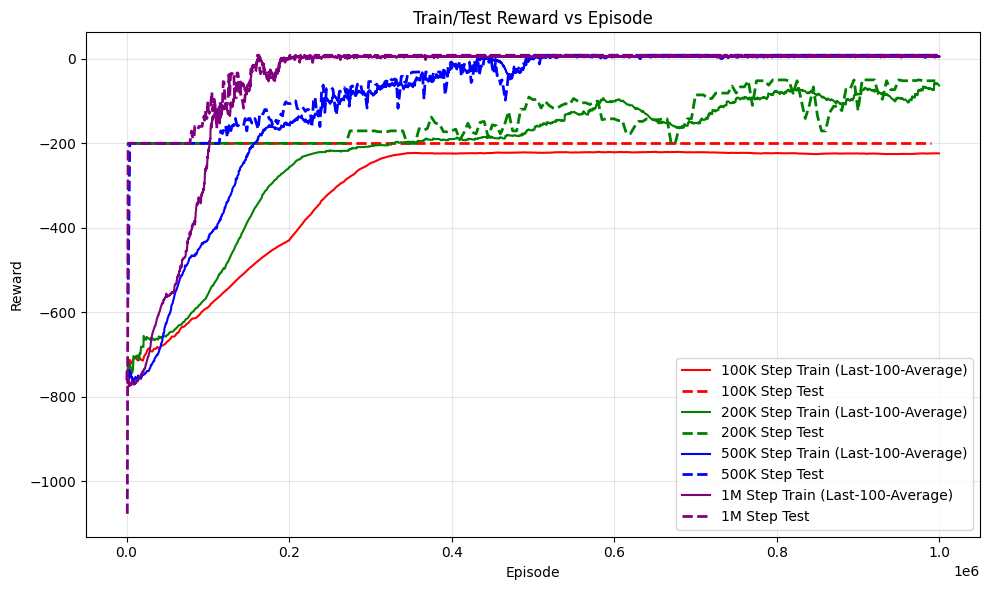

In [14]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

total_steps = [int(1e5), int(2e5), int(5e5), int(1e6)]
steps = ["100K", "200K", "500K", "1M"]
steps_frequency = [10, 5, 2, 1]
colors = ["red", "green", "blue", "purple"]

plt.figure(figsize=(10, 6))

for total_step, step, step_frequency, color in zip(total_steps, steps, steps_frequency, colors):

    for run in range(1, 2):
        log_file = f"weights/DQN-Taxi-v4-{step}-run{run}-log.pickle"
        window = 100
        test_frequency = config.test_frequency   

        try:
            with open(log_file, "rb") as f:
                log = pickle.load(f)
        except:
            continue

        episode_rewards = np.array(log["episode_rewards"])
        test_episode_rewards = np.array(log["test_episode_rewards"]).mean(-1)

        train_episode = np.array(log["episode_steps"])
        for i in range(1, len(train_episode)):
            train_episode[i] += train_episode[i-1]
        test_episode = np.arange(config.test_frequency, total_step, config.test_frequency)

    sum_episode_rewards = np.convolve(episode_rewards, np.ones((window,), dtype=np.float32))[:len(episode_rewards)]
    mean_episode_rewards = sum_episode_rewards / np.array([i+1 if i < window else window for i in range(len(episode_rewards))])

    # sum_test_episode_rewards = np.convolve(test_episode_rewards, np.ones((window,), dtype=np.float32))[:len(test_episode_rewards)]
    # mean_test_episode_rewards = sum_test_episode_rewards / np.array([i+1 if i < window else window for i in range(len(test_episode_rewards))])

    plt.plot(
        train_episode * step_frequency,
        mean_episode_rewards,
        label=f"{step} Step Train (Last-{window}-Average)",
        color = color
    )

    plt.plot(
        test_episode * step_frequency,
        test_episode_rewards, #mean_test_episode_rewards,
        linestyle = "--",
        linewidth=2,
        label=f"{step} Step Test", #f"{step} Step Test (Last-{window}-Average)",
        color = color
    )

plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Train/Test Reward vs Episode")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
steps = ["100K", "100K-Bz10K", "100K-Bz50K",
         "200K", "200K-Bz10K", "200K-Bz50K",
         "500K", "1M"]
rewards = [[] for _ in range(len(steps))]

for i, step in enumerate(steps):
    for run in range(1, 11):
        log_file = f"weights/DQN-Taxi-v4-{step}-run{run}-log.pickle"

        try:
            with open(log_file, "rb") as f:
                log = pickle.load(f)
                test_rewards = np.array(log["test_episode_rewards"])
                test_rewards = test_rewards.mean(-1)
                test_rewards = test_rewards.max()
            
                rewards[i].append(test_rewards)
        except:
            continue

rewards = np.array(rewards)

pd.DataFrame(data = {"step": steps, "mean": rewards.mean(-1), "std": rewards.std(-1),
                     "min": rewards.min(-1), "max": rewards.max(-1)})

,step,mean,std,min,max
0,100K,-200.000,0.000000e+00,-200.00,-200.00
1,100K-Bz10K,-200.000,0.000000e+00,-200.00,-200.00
2,100K-Bz50K,-200.000,0.000000e+00,-200.00,-200.00
3,200K,-103.275,5.073821e+01,-200.00,-49.67
4,200K-Bz10K,-134.397,3.228148e+01,-183.11,-77.19
5,200K-Bz50K,-107.379,6.861678e+01,-185.18,6.58
6,500K,8.594,4.651881e-02,8.46,8.62
7,1M,8.620,1.776357e-15,8.62,8.62
